In [129]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [130]:
#Load Iris dataset
iris = load_iris()
# print(iris.DESCR)
X_iris = iris.data
y_iris = iris.target
print("First sample:", X_iris[0], y_iris[0])
print(y_iris)
#Check the shape of data
print (X_iris.shape)

#Check if sets balanced
print ('Data: {}, 2: {}, 3: {}'.format(np.sum(y_iris == 0), np.sum(y_iris == 1), np.sum(y_iris == 2) ) )



First sample: [5.1 3.5 1.4 0.2] 0
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
(150, 4)
Data: 50, 2: 50, 3: 50


'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.


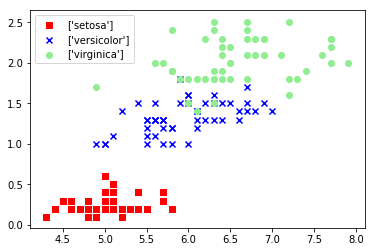

In [131]:
# X_twoFeature = iris.data[:, [0,1]]  # we only take the first two features.
X_twoFeature = iris.data[:, [0,3]] 
y = iris.target
markers = ('s', 'x', 'o')
colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
cmap = ListedColormap(colors[:len(np.unique(y))])
plt.scatter(x=X_twoFeature[y == 0, 0], y=X_twoFeature[y == 0, 1], c=cmap(0), marker=markers[0], label=[iris.target_names[0]])
plt.scatter(x=X_twoFeature[y == 1, 0], y=X_twoFeature[y == 1, 1], c=cmap(1), marker=markers[1], label=[iris.target_names[1]])
plt.scatter(x=X_twoFeature[y == 2, 0], y=X_twoFeature[y == 2, 1], c=cmap(2), marker=markers[2], label=[iris.target_names[2]])
plt.legend()

In [132]:
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=cmap(idx),
                    marker=markers[idx], label=cl)
    
    # highlight test samples
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1], alpha=1.0, c='yellow', linewidth=1, marker='>',
                   s=55, label="test set")

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for

The accuracy score using scikit-learn is 0.7555555555555555
The model parameters using scikit learn
[[ 0.38370529 -4.04425498]
 [-0.20728736  0.3521255 ]
 [-0.69705278  3.63741105]]
confusion_matrix
[[16  1  0]
 [ 0  7  0]
 [ 0 10 11]]


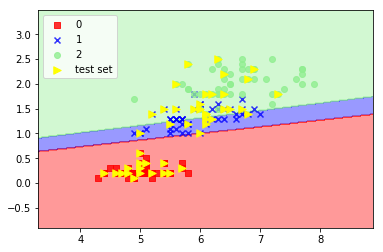

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X_twoFeature, y, test_size=0.3, random_state=0)
#Create estimator class
model_two = LogisticRegression()
# print(model)
model_two.fit(X_train, y_train)
parameters = model_two.coef_
predicted_classes = model_two.predict(X_test)
accuracy = accuracy_score(predicted_classes,y_test)
print('The accuracy score using scikit-learn is {}'.format(accuracy))
print("The model parameters using scikit learn")
print(parameters)
print("confusion_matrix")
print(confusion_matrix(predicted_classes,y_test))

X_combined= np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X=X_combined, y=y_combined, classifier=model_two, test_idx=range(105,150))
plt.legend(loc='upper left')
plt.show()

In [135]:
#Make split for original data
(X_tr_o, X_ts_o, y_tr_o, y_ts_o ) = train_test_split(X_iris, y_iris, stratify=y_iris, test_size= 0.3, random_state=0)
print(X_tr_o.shape)
print(y_tr_o.shape)
print(X_ts_o.shape)
print(y_ts_o.shape)

(105, 4)
(105,)
(45, 4)
(45,)


In [136]:
#Create estimator class
model = LogisticRegression(C = 5, penalty='l2')
print(model)
model.fit(X_tr_o, y_tr_o)
parameters = model.coef_
predicted_classes = model.predict(X_ts_o)
accuracy = accuracy_score(predicted_classes,y_ts_o)
print('The accuracy score using scikit-learn is {}'.format(accuracy))
print("The model parameters using scikit learn")
print(parameters)
print("confusion_matrix")
print(confusion_matrix(predicted_classes,y_ts_o))

LogisticRegression(C=5, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)
The accuracy score using scikit-learn is 0.9777777777777777
The model parameters using scikit learn
[[ 0.56428678  1.83619256 -2.93831054 -1.34766001]
 [-0.14949131 -1.7618203   1.19900041 -2.40918596]
 [-2.14820036 -2.52311139  3.3092415   4.14235276]]
confusion_matrix
[[15  0  0]
 [ 0 15  1]
 [ 0  0 14]]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
